# 03 — HiRISE overlay: confirm polygons land on actual boulders

Visual verification of the BoulderNet outputs against the HiRISE imagery. Two images:

- **ESP_069669_2220** — `.prj` was already trusted (`D_MARS` datum, correct SP1).
- **ESP_047976_2020** — `.prj` had the buggy `D_unnamed` + `SP1=0` fingerprint; SP1
  was overridden with PDS `CENTER_LATITUDE=20` for the CTX-CRS reprojection cache.

**Important insight discovered while building this notebook:** the JP2's own embedded
CRS metadata is ALSO buggy for ESP_047976_2020 (HiRISE PDS RDR pipeline has the same
mis-labelling — `DATUM["unnamed"]`, `SP1=0`). The shapefile inherited it from the
upstream JP2. Crucially though, the JP2 and the shapefile **share the same bug** —
their projected (x, y) coords live in the same metric space. Coordinates relative
to each other are correct; only the (x, y) → (lon, lat) interpretation is broken.

So the overlay here uses **raw shapefile + raw JP2 in their shared projected space**.
No reprojection. If the polygons land on boulders in the imagery, both the geometry
and the relative positioning are correct, and the SP1 correction we applied earlier
is the right fix for downstream geographic work (CTX reprojection, sanity check).

Decimated stream is ~5 m/px (cached to `cache/hirise_decimated/`). Zoom window is
read near native (~50 cm/px) so individual boulders + shadows are visible.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import CRS

from src import detections, hirise_imagery, manifest as M
from src.config import load_config, REPO_ROOT
from src.ctx_retrieve import resolve_target_crs

# Dataset selector: defaults to the vClaire 40-image v2 dataset; set "config.yaml" for v1.
CONFIG_NAME = "config_v2.yaml"
OBS_IDS = ['ESP_069669_2220', 'ESP_047976_2020']   # in both v1+v2; under v2 = denser vClaire detections
FIG_DIR = REPO_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config(CONFIG_NAME)
df = M.load_manifest(cfg.manifest_path).set_index('ObsId')
target_wkt = resolve_target_crs(cfg)
print('config:', CONFIG_NAME, '  detections_root:', cfg.detections_root.name)
print('CTX target CRS:', CRS.from_user_input(target_wkt).name)

config: config_v2.yaml   detections_root: hirise_40_vClaire
CTX target CRS: Mars_2000_Equidistant_Cylindrical


In [2]:
# Pre-load: ensure both images are reprojected (SP1 fix applied if needed) and cached.
for obs in OBS_IDS:
    row = df.loc[obs]
    gdf_t, gpkg, correction = detections.stage1_one_image(
        obs,
        detections_root=cfg.detections_root,
        target_crs=target_wkt,
        cache_dir=cfg.cache_dir,
        config_hash=cfg.hash,
        manifest_row=row,
    )
    print(f'{obs}: {len(gdf_t)} polygons, status={correction["status"]}'
          + (f', SP1 {correction["original_sp1_deg"]} -> {correction["corrected_sp1_deg"]}'
             if correction['status'] != 'trusted_prj' else ''))

ESP_069669_2220: 35238 polygons, status=trusted_prj


ESP_047976_2020: 14835 polygons, status=sp1_corrected_from_pds_label, SP1 0.0 -> 20.0


  reading ESP_069669_2220 imagery... 

shape=(3170, 1486)


  reading ESP_047976_2020 imagery... 

shape=(3242, 1417)


saved C:\Users\brian\Documents\PhD\HiRiseToCTXBoulders\hirise2ctx\reports\figures\03_hirise_overlay_full.png


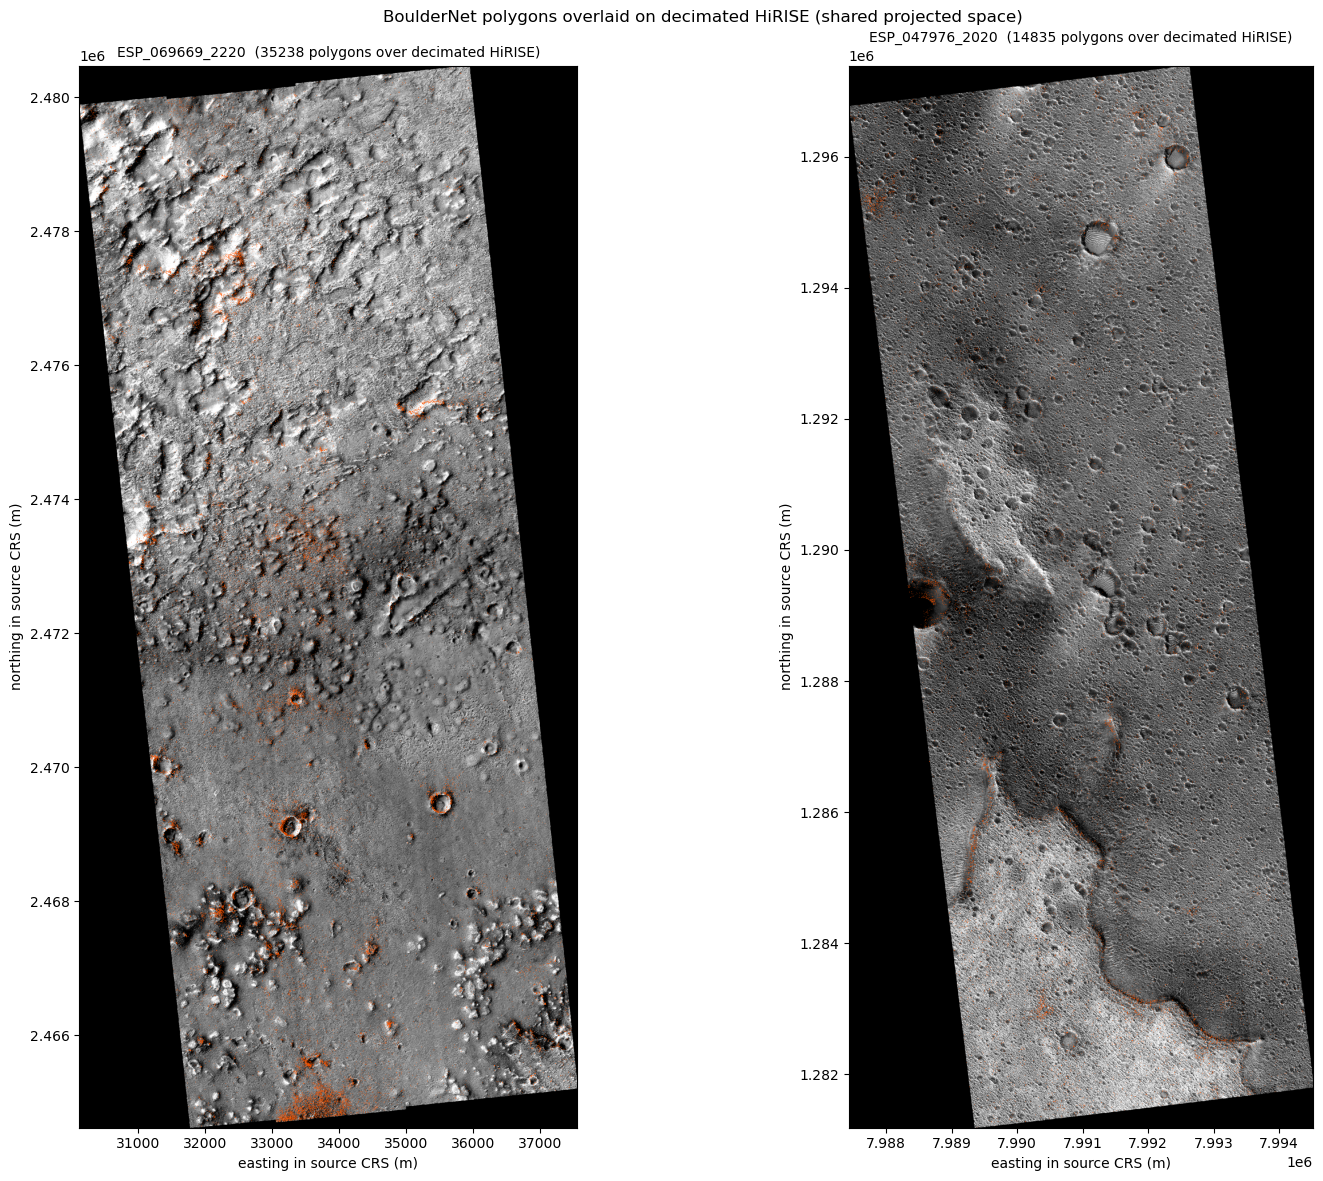

In [3]:
def stretch(arr, low_pct=2, high_pct=98):
    """Linear contrast stretch (HiRISE is 10-bit; full-range view is dark)."""
    lo, hi = np.percentile(arr[arr > 0], [low_pct, high_pct])
    return np.clip((arr.astype(np.float32) - lo) / (hi - lo + 1e-9), 0, 1)


def overlay_full(obs_id, ax):
    """Plot decimated HiRISE imagery + raw BoulderNet polygons in their shared
    projected coordinate space. No reprojection — both sides use whatever CRS the
    JP2/.prj declares, which may be buggy but is self-consistent.
    """
    row = df.loc[obs_id]
    print(f'  reading {obs_id} imagery...', end=' ', flush=True)
    arr, tfm, _src_crs = hirise_imagery.read_full_footprint_decimated(
        obs_id, row['JP2_URL'], cfg.cache_dir, target_mpp=5.0,
    )
    print(f'shape={arr.shape}')
    # Raw shapefile — keep its native CRS metadata even though it may be buggy. The
    # geometry coords share the JP2's space.
    shp = manifest_mod.find_shapefile(obs_id, cfg.detections_root)
    polys_raw = gpd.read_file(shp)

    h, w = arr.shape
    left = tfm.c; top = tfm.f
    right = left + w * tfm.a
    bottom = top + h * tfm.e

    ax.imshow(stretch(arr), extent=(left, right, bottom, top), cmap='gray', origin='upper')
    polys_raw.plot(ax=ax, facecolor='none', edgecolor='#ff5500', linewidth=0.4, alpha=0.85)
    ax.set_aspect('equal')
    ax.set_title(f'{obs_id}  ({len(polys_raw)} polygons over decimated HiRISE)', fontsize=10)
    ax.set_xlabel('easting in source CRS (m)')
    ax.set_ylabel('northing in source CRS (m)')
    return arr, tfm, polys_raw


from src import manifest as manifest_mod
fig, axes = plt.subplots(1, 2, figsize=(16, 12))
results = {}
for ax, obs in zip(axes, OBS_IDS):
    results[obs] = overlay_full(obs, ax)
fig.suptitle('BoulderNet polygons overlaid on decimated HiRISE (shared projected space)', fontsize=12)
fig.tight_layout()
out = FIG_DIR / '03_hirise_overlay_full.png'
fig.savefig(out, dpi=150)
print('saved', out)

saved C:\Users\brian\Documents\PhD\HiRiseToCTXBoulders\hirise2ctx\reports\figures\03_hirise_overlay_zoom.png


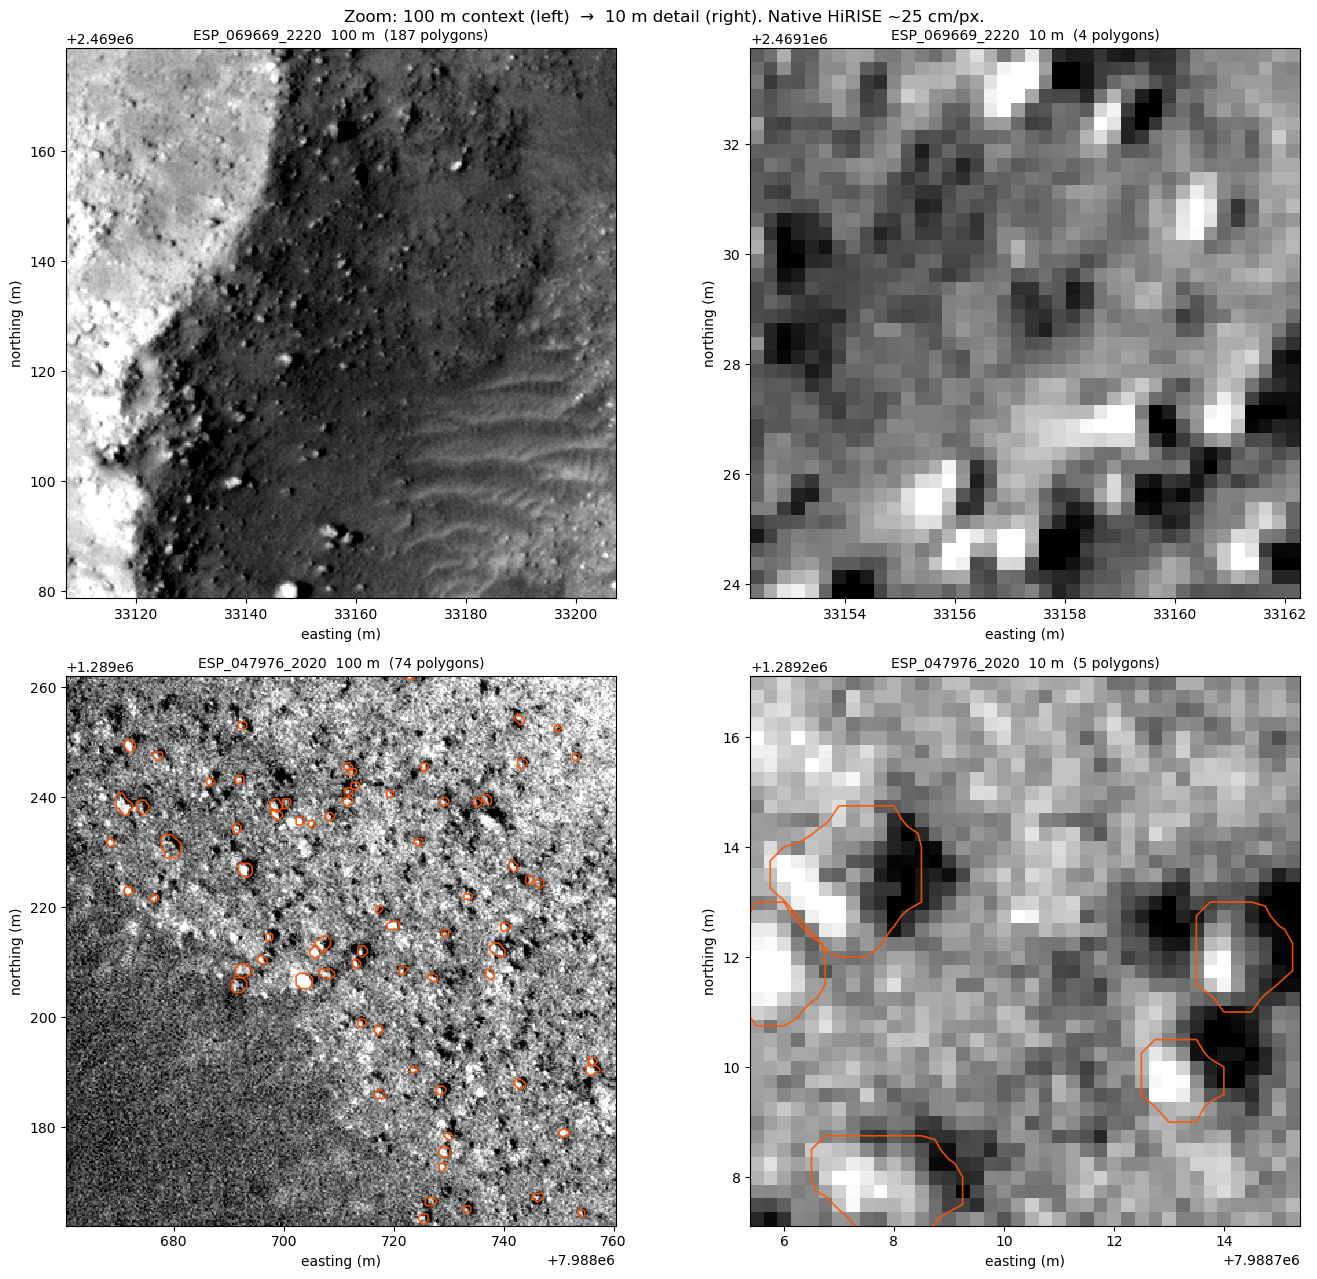

In [4]:
# Multi-scale zoom: 100 m context + 10 m detail per image. Both crop from the locally
# cached JP2 — instant. Centered on the densest polygon cluster at the 100 m scale so
# the 10 m detail view lands inside the cluster, not between boulders.
ZOOM_HALF_M_CONTEXT = 50.0   # full window 100 m  -> ~400 native px
ZOOM_HALF_M_DETAIL = 5.0     # full window 10 m   -> ~40 native px


def densest_zoom_center(polys: gpd.GeoDataFrame, window_size_m: float) -> tuple[float, float]:
    """Return the (x, y) center of the densest `window_size_m`-square cell containing
    polygon centroids. Uses a 2D histogram stepping at half the window size.
    """
    centroids = polys.geometry.centroid
    xs = np.array([p.x for p in centroids])
    ys = np.array([p.y for p in centroids])
    step = window_size_m / 2.0
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    nx = max(2, int(np.ceil((x_max - x_min) / step)) + 1)
    ny = max(2, int(np.ceil((y_max - y_min) / step)) + 1)
    x_edges = x_min + step * np.arange(nx + 1)
    y_edges = y_min + step * np.arange(ny + 1)
    H, _, _ = np.histogram2d(xs, ys, bins=[x_edges, y_edges])
    iy, ix = np.unravel_index(np.argmax(H.T), H.T.shape)
    return 0.5 * (x_edges[ix] + x_edges[ix + 1]), 0.5 * (y_edges[iy] + y_edges[iy + 1])


def overlay_at_scale(obs_id, ax, half_m, tag, center=None):
    """Plot one zoom level centered at `center` (defaults to densest 100 m cluster)."""
    row = df.loc[obs_id]
    _, _, polys_raw = results[obs_id]
    if len(polys_raw) == 0:
        ax.text(0.5, 0.5, f'{obs_id}\n(0 polygons)', transform=ax.transAxes,
                ha='center', va='center', fontsize=12)
        ax.set_xticks([]); ax.set_yticks([])
        return center
    if center is None:
        center = densest_zoom_center(polys_raw, 2 * ZOOM_HALF_M_CONTEXT)
    cx, cy = center
    bounds = (cx - half_m, cy - half_m, cx + half_m, cy + half_m)
    arr, tfm, _ = hirise_imagery.read_native_window(
        obs_id, row['JP2_URL'], bounds, cfg.cache_dir, window_tag=tag,
    )
    h, w = arr.shape
    left = tfm.c; top = tfm.f
    right = left + w * tfm.a
    bottom = top + h * tfm.e
    ax.imshow(stretch(arr), extent=(left, right, bottom, top), cmap='gray', origin='upper',
              interpolation='nearest')
    sub = polys_raw.cx[bounds[0]:bounds[2], bounds[1]:bounds[3]]
    sub.plot(ax=ax, facecolor='none', edgecolor='#ff5500', linewidth=1.2, alpha=0.9)
    ax.set_aspect('equal')
    ax.set_xlim(left, right); ax.set_ylim(bottom, top)
    ax.set_title(f'{obs_id}  {2*half_m:.0f} m  ({len(sub)} polygons)', fontsize=10)
    ax.set_xlabel('easting (m)'); ax.set_ylabel('northing (m)')
    return center


fig, axes = plt.subplots(2, 2, figsize=(14, 13))
for row_idx, obs in enumerate(OBS_IDS):
    center = overlay_at_scale(obs, axes[row_idx, 0], ZOOM_HALF_M_CONTEXT, 'zoom_100m')
    overlay_at_scale(obs, axes[row_idx, 1], ZOOM_HALF_M_DETAIL, 'zoom_10m', center=center)
fig.suptitle('Zoom: 100 m context (left)  →  10 m detail (right). Native HiRISE ~25 cm/px.',
             fontsize=12)
fig.tight_layout()
out = FIG_DIR / '03_hirise_overlay_zoom.png'
fig.savefig(out, dpi=150)
print('saved', out)